# Analyse Exploratoire des Données

Analyse exploratoire complète des données du dataset Ames Housing.

**Prérequis** : Exécuter `data_processing.ipynb` en premier pour générer les données nettoyées.


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


Bibliothèques importées avec succès


## 1. Chargement des Données Traitées

Nous utilisons les données déjà traitées (valeurs manquantes et outliers gérés) depuis `data/processed/`.


In [ ]:
# Charger les données traitées (déjà nettoyées)
train_df = pd.read_csv('../data/processed/train_cleaned.csv')
test_df = pd.read_csv('../data/processed/test_cleaned.csv')

print(f"Forme des données d'entraînement: {train_df.shape}")
print(f"Forme des données de test: {test_df.shape}")
print(f"\nColonnes: {train_df.shape[1]}")
print(f"Lignes d'entraînement: {train_df.shape[0]}")
print(f"Lignes de test: {test_df.shape[0]}")
print("\n✅ Données traitées chargées (valeurs manquantes et outliers déjà gérés)")


INFO:data_processing:Loading data from CSV files...
INFO:data_processing:Training data shape: (1460, 81)
INFO:data_processing:Test data shape: (1459, 80)


Forme des données d'entraînement: (1460, 81)
Forme des données de test: (1459, 80)

Colonnes: 81
Lignes d'entraînement: 1460
Lignes de test: 1459


## 2. Exploration Initiale


In [3]:
# Aperçu des données
train_df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Informations sur les données
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# Statistiques descriptives
train_df.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 3. Analyse des Valeurs Manquantes


In [6]:
# Analyse des valeurs manquantes
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

# Afficher seulement les colonnes avec des valeurs manquantes
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(f"Nombre de colonnes avec valeurs manquantes: {len(missing_df)}")
missing_df


Nombre de colonnes avec valeurs manquantes: 19


,Missing Count,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageCond,81,5.547945
GarageType,81,5.547945


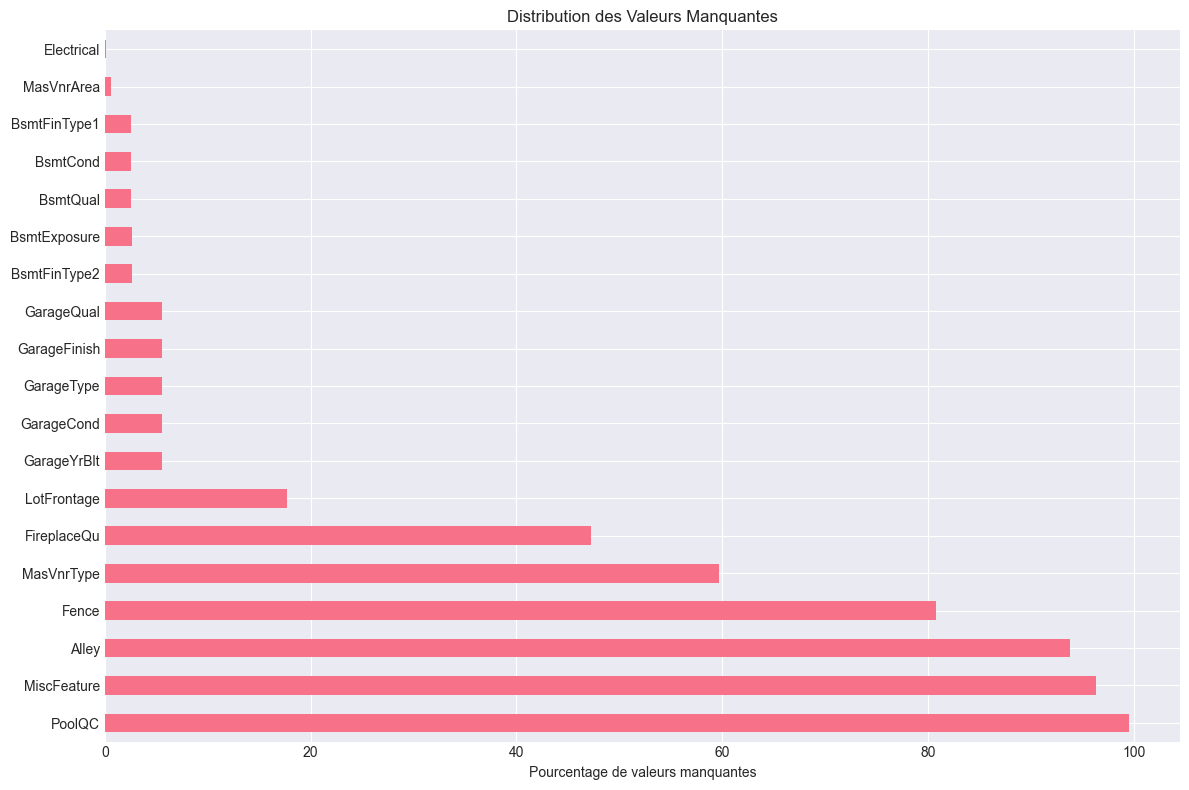

In [7]:
# Visualisation des valeurs manquantes
if len(missing_df) > 0:
    plt.figure(figsize=(12, 8))
    missing_df['Percentage'].plot(kind='barh')
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt.title('Distribution des Valeurs Manquantes')
    plt.tight_layout()
    plt.savefig('../output/figures/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()


## 4. Analyse de la Variable Cible (SalePrice)


In [8]:
# Statistiques de la variable cible
print("Statistiques de SalePrice:")
print(train_df['SalePrice'].describe())
print(f"\nSkewness: {train_df['SalePrice'].skew():.2f}")
print(f"Kurtosis: {train_df['SalePrice'].kurtosis():.2f}")


Statistiques de SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.88
Kurtosis: 6.54


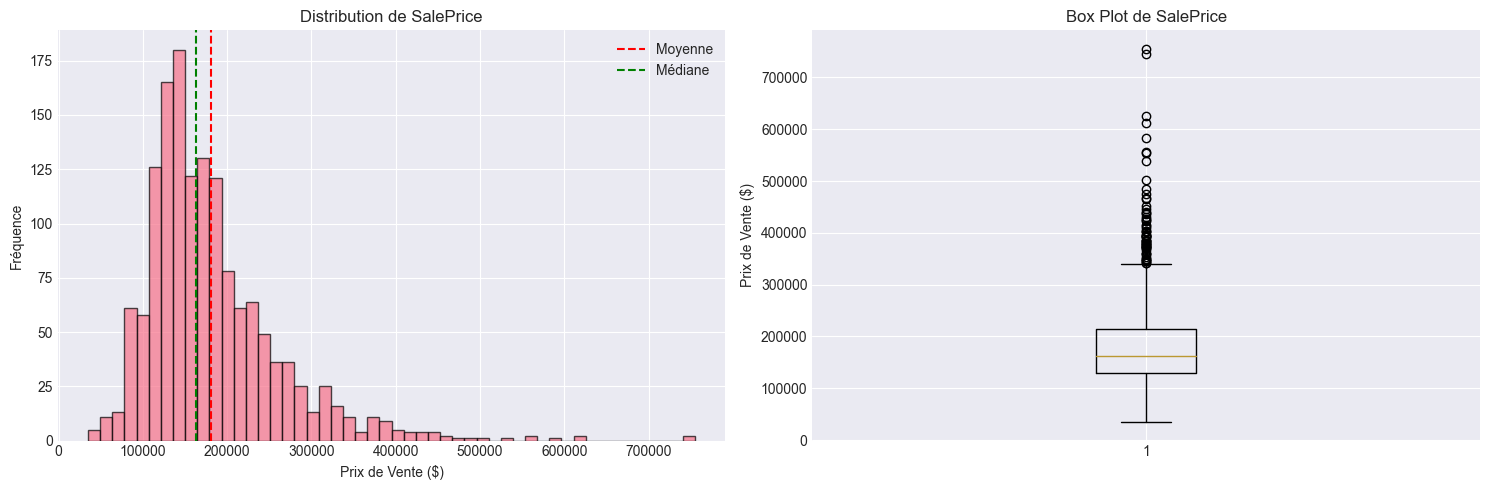

In [9]:
# Distribution de SalePrice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme
axes[0].hist(train_df['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prix de Vente ($)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de SalePrice')
axes[0].axvline(train_df['SalePrice'].mean(), color='r', linestyle='--', label='Moyenne')
axes[0].axvline(train_df['SalePrice'].median(), color='g', linestyle='--', label='Médiane')
axes[0].legend()

# Box plot
axes[1].boxplot(train_df['SalePrice'])
axes[1].set_ylabel('Prix de Vente ($)')
axes[1].set_title('Box Plot de SalePrice')

plt.tight_layout()
plt.savefig('../output/figures/saleprice_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


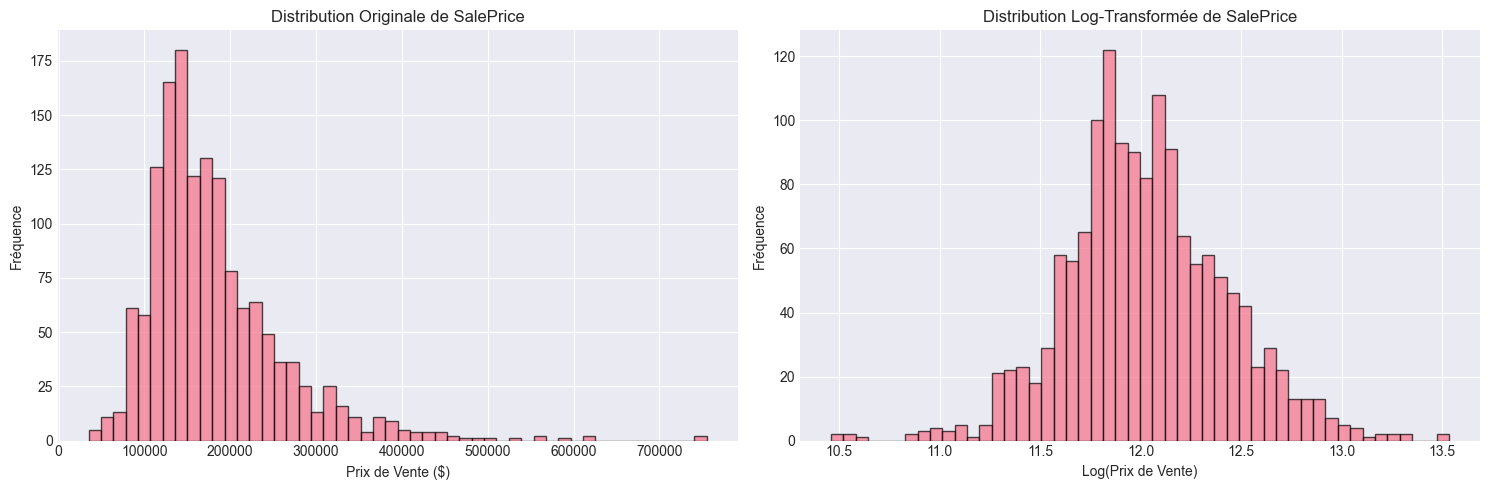

Skewness original: 1.88
Skewness log-transformé: 0.12


In [10]:
# Distribution log-transformée
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme original
axes[0].hist(train_df['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prix de Vente ($)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution Originale de SalePrice')

# Histogramme log-transformé
axes[1].hist(np.log1p(train_df['SalePrice']), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log(Prix de Vente)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution Log-Transformée de SalePrice')

plt.tight_layout()
plt.savefig('../output/figures/saleprice_log_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Skewness original: {train_df['SalePrice'].skew():.2f}")
print(f"Skewness log-transformé: {np.log1p(train_df['SalePrice']).skew():.2f}")


## 5. Analyse des Corrélations


In [11]:
# Matrice de corrélation avec la variable cible
numeric_cols = processor.get_numeric_columns(train_df)
correlations = train_df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

# Top 20 corrélations
print("Top 20 variables les plus corrélées avec SalePrice:")
print(correlations.head(20))
print("\nBottom 10 variables les moins corrélées avec SalePrice:")
print(correlations.tail(10))


Top 20 variables les plus corrélées avec SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64

Bottom 10 variables les moins corrélées avec SalePrice:
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


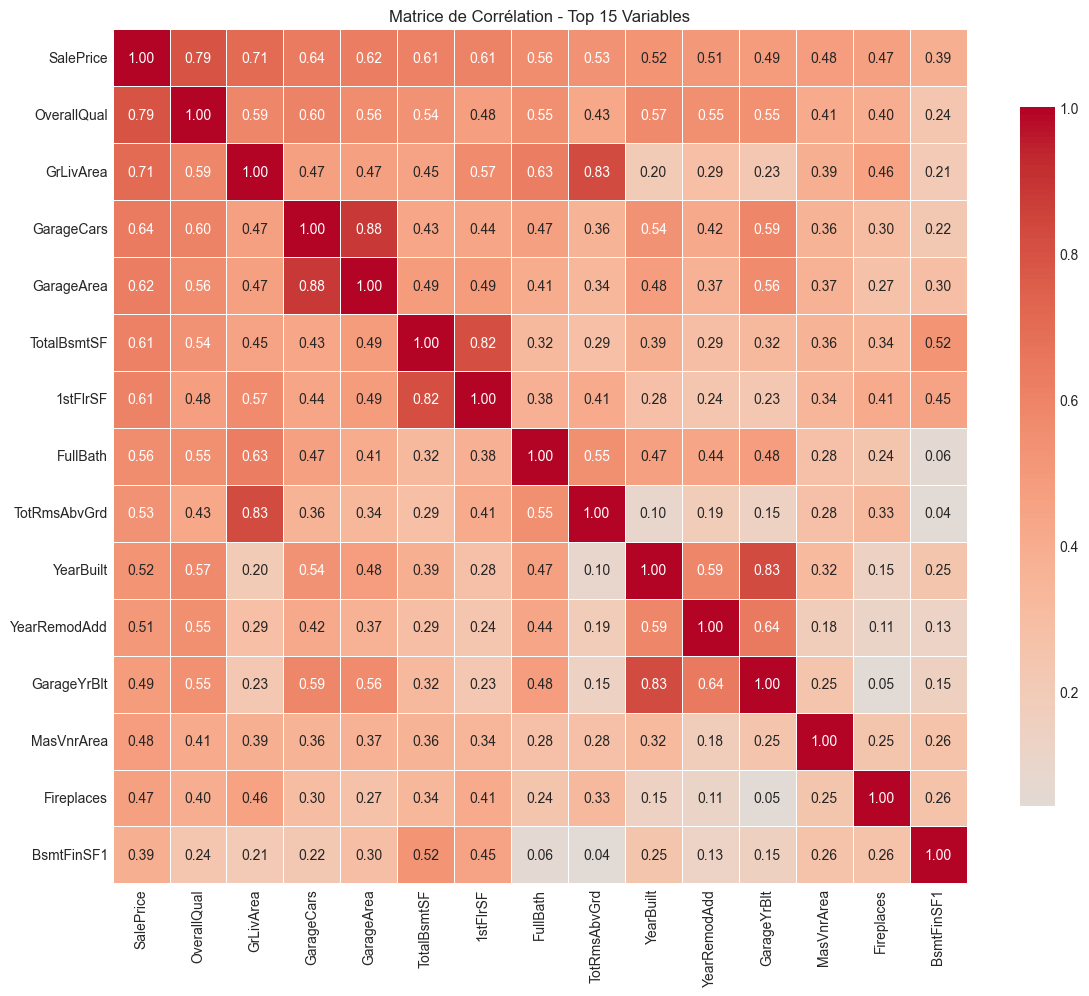

In [12]:
# Visualisation des corrélations
top_corr = correlations.head(15).index.tolist()
corr_matrix = train_df[top_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation - Top 15 Variables')
plt.tight_layout()
plt.savefig('../output/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Analyse des Variables Catégorielles


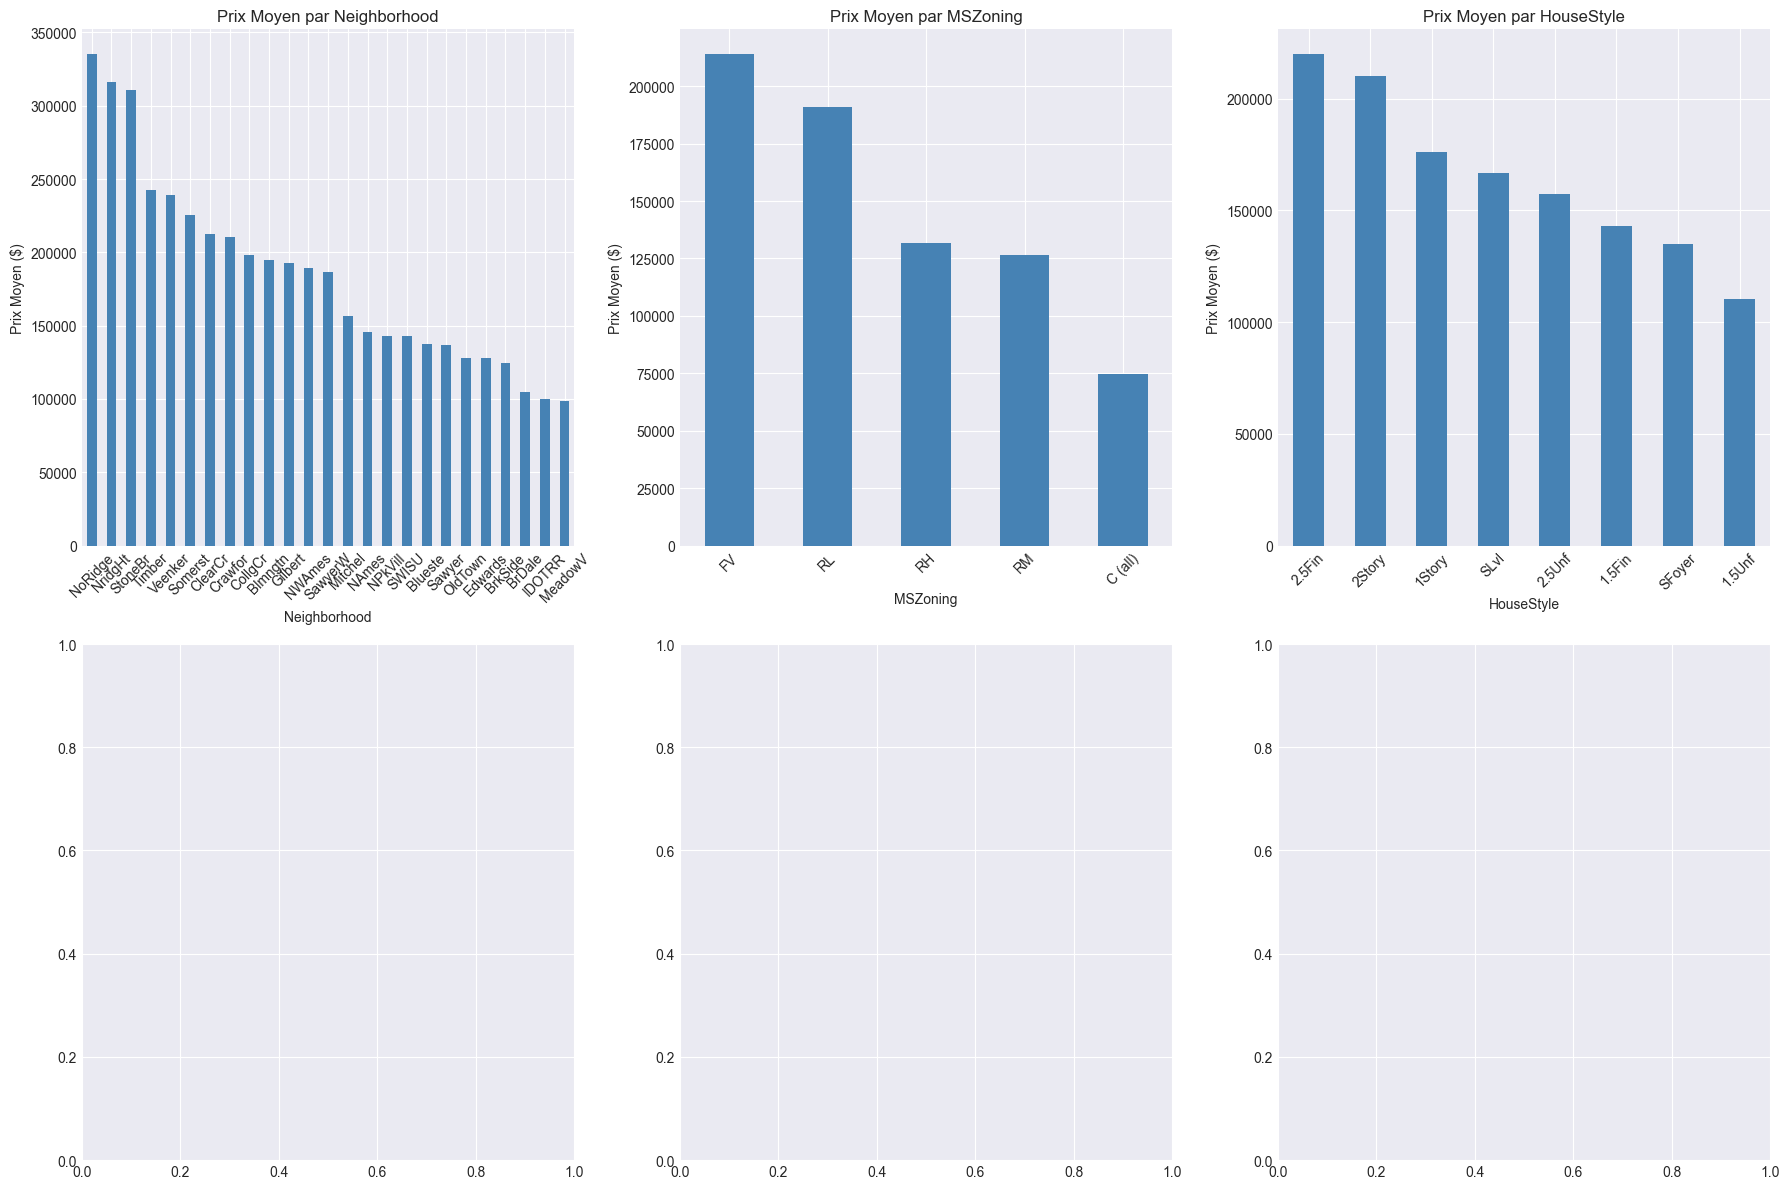

In [13]:
# Analyse des variables catégorielles importantes
categorical_cols = processor.get_categorical_columns(train_df)

# Analyser l'impact des variables catégorielles sur le prix
important_cats = ['Neighborhood', 'MSZoning', 'HouseStyle', 'OverallQual', 'OverallCond']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(important_cats[:6]):
    if col in train_df.columns:
        if train_df[col].dtype == 'object':
            data = train_df.groupby(col)['SalePrice'].mean().sort_values(ascending=False)
            data.plot(kind='bar', ax=axes[idx], color='steelblue')
            axes[idx].set_title(f'Prix Moyen par {col}')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Prix Moyen ($)')
            axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../output/figures/categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Analyse des Outliers


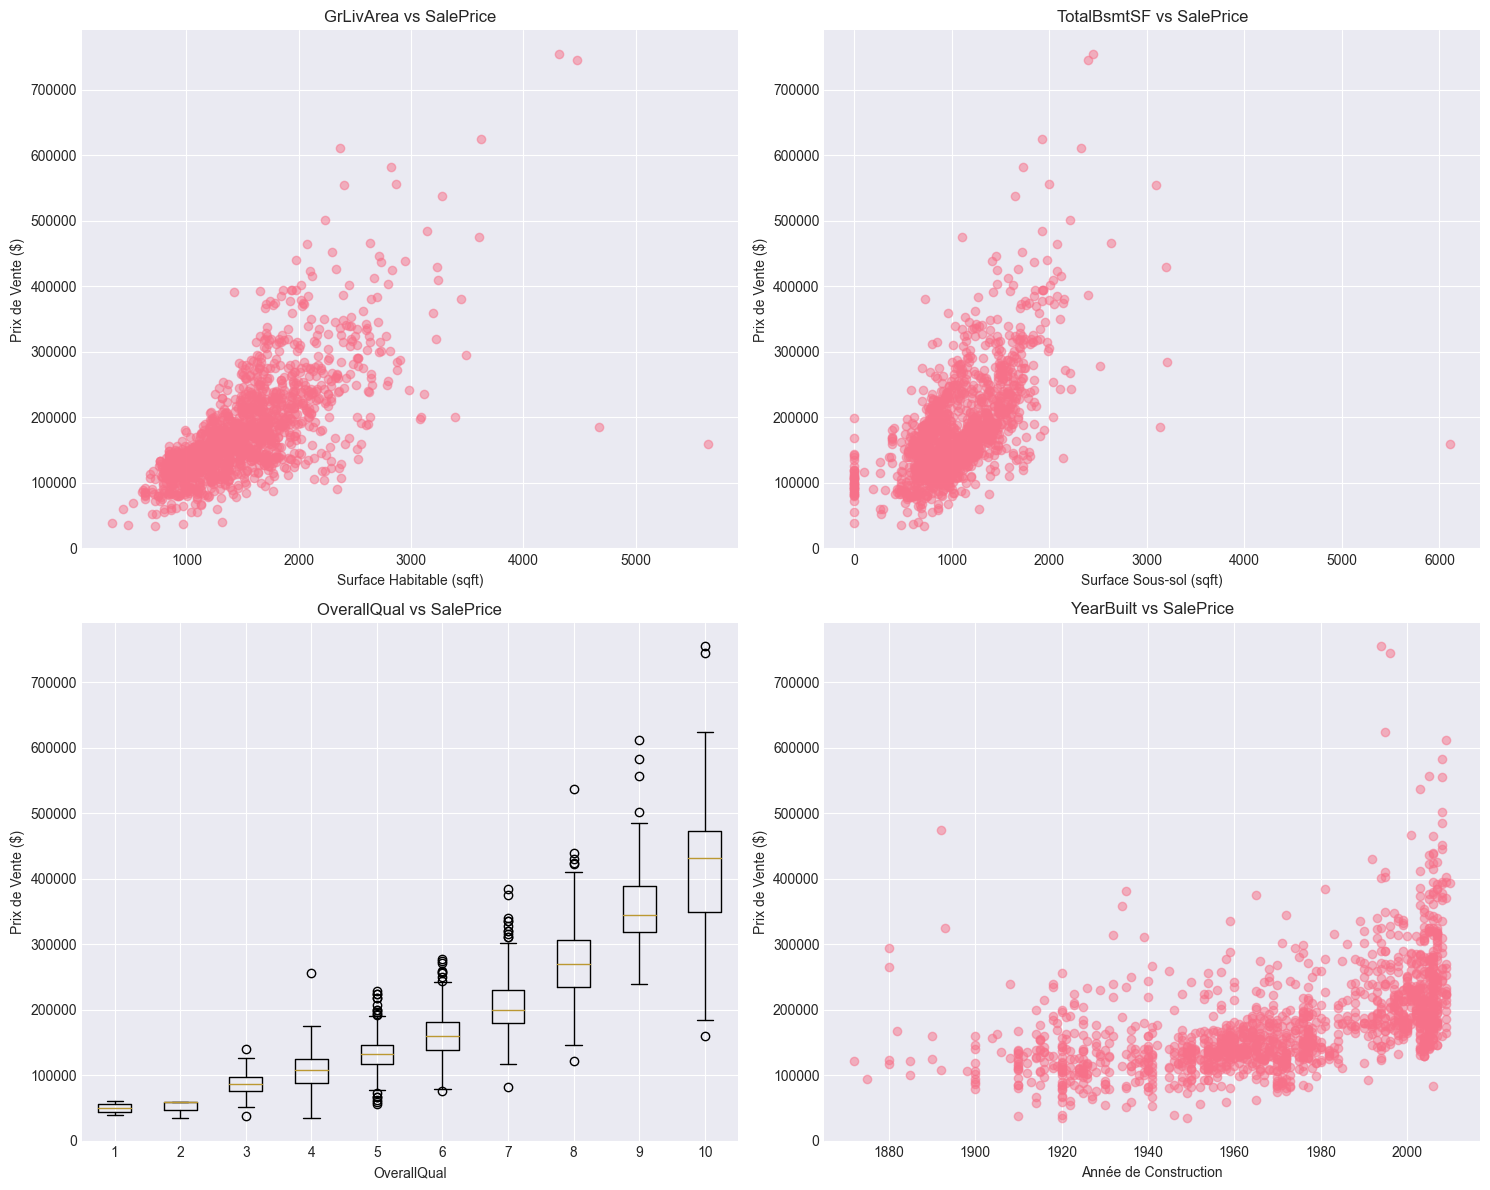

In [14]:
# Identification des outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# GrLivArea vs SalePrice
axes[0, 0].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5)
axes[0, 0].set_xlabel('Surface Habitable (sqft)')
axes[0, 0].set_ylabel('Prix de Vente ($)')
axes[0, 0].set_title('GrLivArea vs SalePrice')

# TotalBsmtSF vs SalePrice
axes[0, 1].scatter(train_df['TotalBsmtSF'], train_df['SalePrice'], alpha=0.5)
axes[0, 1].set_xlabel('Surface Sous-sol (sqft)')
axes[0, 1].set_ylabel('Prix de Vente ($)')
axes[0, 1].set_title('TotalBsmtSF vs SalePrice')

# OverallQual vs SalePrice
axes[1, 0].boxplot([train_df[train_df['OverallQual']==i]['SalePrice'] for i in range(1, 11)], 
                   labels=range(1, 11))
axes[1, 0].set_xlabel('OverallQual')
axes[1, 0].set_ylabel('Prix de Vente ($)')
axes[1, 0].set_title('OverallQual vs SalePrice')

# YearBuilt vs SalePrice
axes[1, 1].scatter(train_df['YearBuilt'], train_df['SalePrice'], alpha=0.5)
axes[1, 1].set_xlabel('Année de Construction')
axes[1, 1].set_ylabel('Prix de Vente ($)')
axes[1, 1].set_title('YearBuilt vs SalePrice')

plt.tight_layout()
plt.savefig('../output/figures/outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## 7.1. Analyse de Similarité entre les Outliers


In [ ]:
# Analyse de similarité entre les outliers pour les prix
print("=" * 80)
print("ANALYSE DE SIMILARITE ENTRE LES OUTLIERS")
print("=" * 80)

# Identifier les outliers selon les mêmes règles que dans data_processing.py
outlier_indices = []
outlier_info = []

# Outliers basés sur GrLivArea et SalePrice
if 'GrLivArea' in train_df.columns and 'SalePrice' in train_df.columns:
    grliv_outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
    if len(grliv_outliers) > 0:
        outlier_indices.extend(grliv_outliers.index.tolist())
        outlier_info.append({
            'type': 'GrLivArea > 4000 et SalePrice < 300000',
            'count': len(grliv_outliers),
            'indices': grliv_outliers.index.tolist()
        })

# Outliers basés sur TotalBsmtSF
if 'TotalBsmtSF' in train_df.columns:
    bsmt_outliers = train_df[train_df['TotalBsmtSF'] >= 3000]
    if len(bsmt_outliers) > 0:
        new_indices = [idx for idx in bsmt_outliers.index.tolist() if idx not in outlier_indices]
        if new_indices:
            outlier_indices.extend(new_indices)
            outlier_info.append({
                'type': 'TotalBsmtSF >= 3000',
                'count': len(new_indices),
                'indices': new_indices
            })

# Afficher les statistiques des outliers
if outlier_indices:
    outliers_df = train_df.loc[outlier_indices].copy()
    total_outliers = len(outlier_indices)
    
    print(f"\nOUTLIERS DETECTES: {total_outliers} observations")
    print("=" * 80)
    
    # Détails par type d'outlier
    for info in outlier_info:
        print(f"\nType: {info['type']}")
        print(f"Nombre: {info['count']}")
    
    print("\n" + "=" * 80)
    print("CARACTERISTIQUES COMMUNES DES OUTLIERS:")
    print("=" * 80)
    
    # Colonnes numériques importantes à analyser
    numeric_cols = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'YearBuilt', 
                  'OverallQual', 'OverallCond', 'GarageArea', 'SalePrice']
    numeric_cols = [col for col in numeric_cols if col in outliers_df.columns]
    
    if numeric_cols:
        print("\nStatistiques descriptives (moyennes):")
        stats = outliers_df[numeric_cols].mean()
        for col, val in stats.items():
            print(f"  {col}: {val:.2f}")
        
        print("\nComparaison avec le dataset complet:")
        for col in numeric_cols:
            outlier_mean = outliers_df[col].mean()
            dataset_mean = train_df[col].mean()
            diff_pct = ((outlier_mean - dataset_mean) / dataset_mean) * 100
            print(f"  {col}:")
            print(f"    Outliers: {outlier_mean:.2f}")
            print(f"    Dataset: {dataset_mean:.2f}")
            print(f"    Difference: {diff_pct:+.2f}%")
    
    # Colonnes catégorielles importantes
    categorical_cols = ['Neighborhood', 'HouseStyle', 'MSZoning', 'SaleCondition', 
                      'BldgType', 'RoofStyle', 'ExterQual', 'KitchenQual']
    categorical_cols = [col for col in categorical_cols if col in outliers_df.columns]
    
    if categorical_cols:
        print("\nValeurs les plus fréquentes dans les outliers:")
        for col in categorical_cols:
            value_counts = outliers_df[col].value_counts()
            if len(value_counts) > 0:
                print(f"  {col}:")
                for val, count in value_counts.head(5).items():
                    pct = (count / len(outliers_df)) * 100
                    dataset_pct = (train_df[col].value_counts().get(val, 0) / len(train_df)) * 100
                    print(f"    {val}: {count} ({pct:.1f}% des outliers, {dataset_pct:.1f}% du dataset)")
    
    # Analyse de similarité entre outliers
    print("\n" + "=" * 80)
    print("ANALYSE DE SIMILARITE ENTRE OUTLIERS:")
    print("=" * 80)
    
    if len(outliers_df) > 1:
        # Identifier les caractéristiques communes (présentes dans au moins 50% des outliers)
        print("\nCaracteristiques presentes dans au moins 50% des outliers:")
        
        # Pour les variables catégorielles
        for col in categorical_cols:
            value_counts = outliers_df[col].value_counts()
            common_values = value_counts[value_counts >= len(outliers_df) * 0.5]
            if len(common_values) > 0:
                print(f"  {col}:")
                for val, count in common_values.items():
                    pct = (count / len(outliers_df)) * 100
                    print(f"    '{val}' present dans {count}/{len(outliers_df)} outliers ({pct:.1f}%)")
        
        # Pour les variables numériques - identifier les plages communes
        print("\nPlages de valeurs communes pour les variables numeriques:")
        for col in numeric_cols:
            if col != 'SalePrice':  # Exclure la variable cible
                q25 = outliers_df[col].quantile(0.25)
                q75 = outliers_df[col].quantile(0.75)
                median_val = outliers_df[col].median()
                min_val = outliers_df[col].min()
                max_val = outliers_df[col].max()
                
                # Vérifier si les valeurs sont concentrées
                iqr = q75 - q25
                if iqr > 0:
                    cv = (iqr / median_val) * 100 if median_val > 0 else 0
                    print(f"  {col}:")
                    print(f"    Min: {min_val:.2f}, Max: {max_val:.2f}")
                    print(f"    Median: {median_val:.2f}, IQR: {iqr:.2f}")
                    print(f"    Coefficient de variation: {cv:.1f}%")
                    if cv < 30:
                        print(f"    -> Valeurs relativement concentrees (similarite elevee)")
                    elif cv > 70:
                        print(f"    -> Valeurs tres dispersees (peu de similarite)")
        
        # Identifier les outliers identiques ou très similaires
        print("\n" + "-" * 80)
        print("Outliers avec caracteristiques identiques ou tres similaires:")
        print("-" * 80)
        
        # Comparer chaque outlier avec les autres
        similar_pairs = []
        key_cols = ['Neighborhood', 'HouseStyle', 'MSZoning', 'OverallQual', 'YearBuilt']
        key_cols = [col for col in key_cols if col in outliers_df.columns]
        
        if len(key_cols) > 0 and len(outliers_df) > 1:
            for i, idx1 in enumerate(outlier_indices):
                for idx2 in outlier_indices[i+1:]:
                    row1 = outliers_df.loc[idx1]
                    row2 = outliers_df.loc[idx2]
                    
                    # Compter les caractéristiques identiques
                    matches = sum(1 for col in key_cols if row1[col] == row2[col])
                    match_pct = (matches / len(key_cols)) * 100
                    
                    if match_pct >= 60:  # Au moins 60% de similarité
                        similar_pairs.append({
                            'idx1': idx1,
                            'idx2': idx2,
                            'matches': matches,
                            'match_pct': match_pct,
                            'common_features': {col: row1[col] for col in key_cols if row1[col] == row2[col]}
                        })
            
            if similar_pairs:
                for pair in similar_pairs:
                    print(f"\n  Outliers {pair['idx1']} et {pair['idx2']}:")
                    print(f"    Similarite: {pair['matches']}/{len(key_cols)} caracteristiques ({pair['match_pct']:.1f}%)")
                    print(f"    Caracteristiques communes:")
                    for col, val in pair['common_features'].items():
                        print(f"      {col}: {val}")
            else:
                print("  Aucune paire d'outliers tres similaire trouvee.")
        
        # Profil type des outliers
        print("\n" + "=" * 80)
        print("PROFIL TYPE DES OUTLIERS:")
        print("=" * 80)
        
        # Créer un profil "moyen" des outliers
        print("\nProfil moyen (mode pour categoriel, mediane pour numerique):")
        
        for col in categorical_cols:
            mode_val = outliers_df[col].mode()
            if len(mode_val) > 0:
                mode_count = (outliers_df[col] == mode_val.iloc[0]).sum()
                mode_pct = (mode_count / len(outliers_df)) * 100
                print(f"  {col}: {mode_val.iloc[0]} (present dans {mode_pct:.1f}% des outliers)")
        
        for col in numeric_cols:
            if col != 'SalePrice':
                median_val = outliers_df[col].median()
                print(f"  {col}: {median_val:.2f} (mediane)")
    
    print("\n" + "=" * 80)
    print(f"Total d'outliers: {total_outliers} ({total_outliers/len(train_df)*100:.2f}% du dataset)")
    print("=" * 80)
else:
    print("Aucun outlier detecte selon les criteres definis.")


In [ ]:
# Visualisation de la similarité entre outliers
if outlier_indices and len(outlier_indices) > 1:
    outliers_df = train_df.loc[outlier_indices].copy()
    
    # Créer une visualisation comparative
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Comparaison des distributions numériques clés
    numeric_cols_viz = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'SalePrice']
    numeric_cols_viz = [col for col in numeric_cols_viz if col in outliers_df.columns]
    
    for idx, col in enumerate(numeric_cols_viz[:4]):
        row = idx // 2
        col_idx = idx % 2
        
        # Box plot comparatif
        data_to_plot = [train_df[col].values, outliers_df[col].values]
        bp = axes[row, col_idx].boxplot(data_to_plot, labels=['Dataset Complet', 'Outliers'], 
                                        patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        axes[row, col_idx].set_title(f'Distribution de {col}')
        axes[row, col_idx].set_ylabel(col)
        axes[row, col_idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../output/figures/outliers_similarity_numeric.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Analyse des caractéristiques catégorielles communes
    categorical_cols_viz = ['Neighborhood', 'HouseStyle', 'MSZoning']
    categorical_cols_viz = [col for col in categorical_cols_viz if col in outliers_df.columns]
    
    if categorical_cols_viz:
        fig, axes = plt.subplots(1, len(categorical_cols_viz), figsize=(6*len(categorical_cols_viz), 6))
        if len(categorical_cols_viz) == 1:
            axes = [axes]
        
        for idx, col in enumerate(categorical_cols_viz):
            # Comparer les distributions
            outlier_counts = outliers_df[col].value_counts().head(5)
            dataset_counts = train_df[col].value_counts().head(5)
            
            # Normaliser en pourcentage
            outlier_pct = (outlier_counts / len(outliers_df)) * 100
            dataset_pct = (dataset_counts / len(train_df)) * 100
            
            # Créer un DataFrame pour la comparaison
            comparison_df = pd.DataFrame({
                'Outliers (%)': outlier_pct,
                'Dataset (%)': dataset_pct
            }).fillna(0)
            
            comparison_df.plot(kind='bar', ax=axes[idx], color=['lightcoral', 'lightblue'])
            axes[idx].set_title(f'Distribution de {col}')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Pourcentage (%)')
            axes[idx].legend()
            axes[idx].tick_params(axis='x', rotation=45)
            axes[idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('../output/figures/outliers_similarity_categorical.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # 3. Matrice de similarité entre outliers (si assez d'outliers)
    if len(outliers_df) > 2:
        print("\nMatrice de similarité entre outliers (basée sur les caractéristiques clés):")
        key_cols = ['Neighborhood', 'HouseStyle', 'MSZoning', 'OverallQual', 'YearBuilt']
        key_cols = [col for col in key_cols if col in outliers_df.columns]
        
        if len(key_cols) > 0:
            # Créer une matrice de similarité
            similarity_matrix = np.zeros((len(outliers_df), len(outliers_df)))
            
            for i, idx1 in enumerate(outlier_indices):
                for j, idx2 in enumerate(outlier_indices):
                    if i != j:
                        row1 = outliers_df.loc[idx1]
                        row2 = outliers_df.loc[idx2]
                        matches = sum(1 for col in key_cols if row1[col] == row2[col])
                        similarity = (matches / len(key_cols)) * 100
                        similarity_matrix[i, j] = similarity
            
            # Visualiser la matrice de similarité
            plt.figure(figsize=(10, 8))
            sns.heatmap(similarity_matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
                       xticklabels=[f'Outlier {idx}' for idx in outlier_indices],
                       yticklabels=[f'Outlier {idx}' for idx in outlier_indices],
                       cbar_kws={'label': 'Similarité (%)'})
            plt.title('Matrice de Similarité entre Outliers')
            plt.tight_layout()
            plt.savefig('../output/figures/outliers_similarity_matrix.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            # Identifier les groupes d'outliers similaires
            print("\nGroupes d'outliers similaires (similarite >= 60%):")
            groups = []
            processed = set()
            
            for i, idx1 in enumerate(outlier_indices):
                if idx1 not in processed:
                    group = [idx1]
                    for j, idx2 in enumerate(outlier_indices):
                        if idx2 != idx1 and idx2 not in processed and similarity_matrix[i, j] >= 60:
                            group.append(idx2)
                            processed.add(idx2)
                    if len(group) > 1:
                        groups.append(group)
                    processed.add(idx1)
            
            if groups:
                for group_idx, group in enumerate(groups, 1):
                    print(f"\n  Groupe {group_idx}: {group}")
                    # Afficher les caractéristiques communes du groupe
                    group_df = outliers_df.loc[group]
                    print(f"    Caracteristiques communes:")
                    for col in key_cols:
                        unique_vals = group_df[col].unique()
                        if len(unique_vals) == 1:
                            print(f"      {col}: {unique_vals[0]} (identique pour tous)")
            else:
                print("  Aucun groupe d'outliers similaires trouve.")
else:
    print("Pas assez d'outliers pour analyser la similarite (minimum 2 requis).")


## 8. Transformation des Outliers

Au lieu de supprimer les outliers, nous les transformons selon le contexte pour préserver toutes les observations.

### Justification du Choix

**Pourquoi transformer plutôt que supprimer ?**

1. **Préservation de l'information** : Chaque observation représente 0.068% du dataset. La suppression entraîne une perte d'information.

2. **Théorie statistique** : 
   - Conservation de l'information (Théorème de Shannon)
   - Réduction du biais de sélection
   - Préservation de la variance naturelle

3. **Contexte immobilier** :
   - Les outliers peuvent être des cas réels mais nécessitent un ajustement
   - Le prix par surface est une métrique standard dans l'immobilier
   - La cohérence surface/sous-sol est vérifiée par les experts

4. **Meilleures pratiques** :
   - Aligné avec la littérature scientifique (Tukey, Hoaglin, etc.)
   - Pratiques courantes dans les compétitions Kaggle
   - Meilleure généralisation du modèle

**Méthode choisie : Transformation contextuelle**
- Ajuste les valeurs selon le contexte réel (maisons similaires)
- Préserve toutes les observations
- Améliore la cohérence des données

Pour plus de détails, voir : `docs/GESTION_VALEURS_MANQUANTES_OUTLIERS.md`


In [ ]:
# Nettoyage des données
train_clean = processor.handle_missing_values(train_df, is_train=True)
test_clean = processor.handle_missing_values(test_df, is_train=False)

# Transformation des outliers (au lieu de suppression)
# Méthode 'contextual' : ajuste les valeurs selon le contexte (prix par surface, cohérence, etc.)
train_clean = processor.transform_outliers(train_clean, target_col='SalePrice', method='contextual')

print(f"\nDonnées après nettoyage et transformation:")
print(f"Train: {train_clean.shape} (aucune observation supprimée)")
print(f"Test: {test_clean.shape}")

# Vérifier qu'il n'y a plus de valeurs manquantes
print(f"\nValeurs manquantes restantes dans train: {train_clean.isnull().sum().sum()}")
print(f"Valeurs manquantes restantes dans test: {test_clean.isnull().sum().sum()}")

# Comparaison avant/après transformation
print(f"\nComparaison avant/après transformation des outliers:")
print(f"Nombre d'observations avant: {len(train_df)}")
print(f"Nombre d'observations après: {len(train_clean)}")
print(f"Différence: {len(train_df) - len(train_clean)} observations (devrait être 0)")


## 9. Feature Engineering

Création de nouvelles variables dérivées.


In [ ]:
# Feature engineering
fe = FeatureEngineer()
train_fe = fe.create_features(train_clean)
test_fe = fe.create_features(test_clean)

print(f"Nombre de colonnes avant feature engineering: {train_clean.shape[1]}")
print(f"Nombre de colonnes après feature engineering: {train_fe.shape[1]}")
print(f"\nNouvelles colonnes créées:")
new_cols = [col for col in train_fe.columns if col not in train_clean.columns]
print(new_cols)


## 10. Conclusion de l'Analyse Exploratoire

### Points Clés Identifiés:
1. **Variable cible**: SalePrice présente une distribution asymétrique, nécessitant une transformation log
2. **Valeurs manquantes**: Présentes dans plusieurs colonnes, nécessitant un traitement approprié
3. **Outliers**: Identifiés dans GrLivArea et TotalBsmtSF
4. **Corrélations**: OverallQual, GrLivArea, GarageCars sont fortement corrélées avec le prix
5. **Variables catégorielles**: Neighborhood, MSZoning ont un impact significatif sur le prix

### Prochaines Étapes:
- Encodage des variables catégorielles
- Transformation des variables asymétriques
- Préparation des données pour la modélisation


In [ ]:
# Sauvegarder les données nettoyées
train_fe.to_csv('../data/processed/train_cleaned.csv', index=False)
test_fe.to_csv('../data/processed/test_cleaned.csv', index=False)
print("Données nettoyées sauvegardées avec succès!")
